# S3E Tutorial: Teaching Images to Speak PDDL

<a target="_blank" href="https://colab.research.google.com/github/guyazran/s3e/blob/main/docs/s3e_walkthrough.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Welcome in. In this notebook, you are going to teach a vision-language pipeline to look at an image, answer planning-relevant questions about it, and hand back a symbolic state that a planner can actually use. That is the core idea behind `s3e`. This package was originally built to support the [S3E paper](https://openreview.net/forum?id=gw4hYNFUIC), but the code has since been redesigned to be modular and reusable for a variety of applications.

We will start with the friendliest possible version of the workflow, where everything is deterministic and easy to inspect. Then, once the moving parts make sense, we will swap in a real small HuggingFace model and watch the same pipeline run for real.

By the end, you should have a feel for both the *shape* of the library and the *rhythm* of using it.


## Package Overview

Here is the whole game in one sentence: `s3e` turns *what a planner cares about* into *questions a model can answer*, then turns the answers back into planner-friendly state. We call this **Semantic Symbolic State Estimation** (S3E).

Under the hood, that means we:

1. read a PDDL domain and problem
2. list every grounded predicate that might matter
3. phrase those predicates as queries
4. ask a vision-language model about one or more images
5. turn the model's response into probabilities or booleans
6. optionally convert the result back into Unified Planning objects

If you only remember four names from the repo, make them these: `SemanticStateEstimator`, `TemplateTranslator`, `VLMBackend`, and `VLMOutput`. Everything else in the tutorial will orbit around those.


In [ ]:
!pip install "git+https://github.com/CLAIR-LAB-TECHNION/s3e"

In [2]:
import os
import sys
import tempfile
import textwrap
import warnings
from pathlib import Path
from pprint import pprint
from unittest.mock import patch

import numpy as np
from PIL import Image, ImageDraw

warnings.filterwarnings("ignore", message=".*IProgress not found.*")
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "s3e").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from s3e import (
    CalibrationExample,
    HuggingFaceVLM,
    IdentityTranslator,
    LLMTranslator,
    PrewrittenTranslator,
    SemanticStateEstimator,
    TemplateTranslator,
    VLMBackend,
    VLMOutput,
)
from s3e.cache import load_cache, make_cache_key, save_cache
from s3e.pddl.up_utils import (
    bool_constant_to_fnode,
    convert_state_dict_to_up_compatible,
    create_up_problem,
    get_all_grounded_predicates_for_objects,
    get_object_names_dict,
    get_pddl_strings,
    ground_predicate_str_to_fnode,
    state_dict_to_up_state,
)

COLOR_BLOCKSWORLD_DOMAIN = """
(define (domain color-blocksworld)
  (:requirements :typing)
  (:types block)
  (:predicates
    (on ?x - block ?y - block)
    (clear ?x - block)
  )
)
"""

COLOR_BLOCKSWORLD_PROBLEM = """
(define (problem color-bw-2)
  (:domain color-blocksworld)
  (:objects blue orange - block)
  (:init (on blue orange) (clear blue))
  (:goal (on orange blue))
)
"""

COLOR_BLOCKSWORLD_PROBLEM_3 = """
(define (problem color-bw-3)
  (:domain color-blocksworld)
  (:objects blue orange green - block)
  (:init (on blue orange) (clear blue) (clear green))
  (:goal (on green blue))
)
"""


def make_color_blocksworld_image() -> Image.Image:
    image = Image.new("RGB", (256, 256), "white")
    draw = ImageDraw.Draw(image)
    draw.rectangle((78, 60, 178, 130), fill="deepskyblue", outline="black", width=3)
    draw.rectangle((78, 130, 178, 200), fill="orange", outline="black", width=3)
    return image


def make_angled_blocksworld_image() -> Image.Image:
    image = Image.new("RGB", (256, 256), "white")
    draw = ImageDraw.Draw(image)

    # Bottom orange block seen from a slight right-side angle.
    draw.polygon([(78, 130), (178, 130), (208, 110), (108, 110)], fill="#ffcc80", outline="black")
    draw.polygon([(178, 130), (208, 110), (208, 180), (178, 200)], fill="#d9822b", outline="black")
    draw.polygon([(78, 130), (178, 130), (178, 200), (78, 200)], fill="orange", outline="black")

    # Top blue block from the same camera angle.
    draw.polygon([(110, 60), (210, 60), (240, 40), (140, 40)], fill="#b3e5ff", outline="black")
    draw.polygon([(210, 60), (240, 40), (240, 110), (210, 130)], fill="#2a99c9", outline="black")
    draw.polygon([(110, 60), (210, 60), (210, 130), (110, 130)], fill="deepskyblue", outline="black")
    return image


TEMPLATE_MAP = {
    "on": "Is the {0} block on top of the {1} block?",
    "clear": "Is the {0} block clear?",
}

print(f"Repository root: {REPO_ROOT}")


Repository root: /Users/guy.azran/Desktop/School/PhD/Code/s3e


## 1. Start from a planning problem

Before we ask a model anything, we need to tell it what world it lives in. In `s3e`, that world comes from a PDDL domain and problem.

For this tutorial, we are keeping the world tiny on purpose: two colored blocks, where `blue` sits on `orange`, and `blue` is clear. Small enough to understand instantly, but rich enough to exercise the full pipeline.


In [3]:
up_problem = create_up_problem(COLOR_BLOCKSWORLD_DOMAIN, COLOR_BLOCKSWORLD_PROBLEM)
grounded_predicates = get_all_grounded_predicates_for_objects(up_problem)

assert up_problem.name == "color-bw-2"
assert len(grounded_predicates) == 6

print("Objects grouped by type:")
pprint(get_object_names_dict(up_problem))
print()
print("All grounded predicates that the estimator will consider:")
pprint(grounded_predicates)


Objects grouped by type:
{'block': ['blue', 'orange']}

All grounded predicates that the estimator will consider:
['on(blue,blue)',
 'on(blue,orange)',
 'on(orange,blue)',
 'on(orange,orange)',
 'clear(blue)',
 'clear(orange)']


That same helper also accepts real `.pddl` files, which is nice because it lets you prototype with strings and then graduate to normal project files without rewriting the rest of your code.


In [4]:
with tempfile.TemporaryDirectory() as tmpdir:
    domain_path = Path(tmpdir) / "domain.pddl"
    problem_path = Path(tmpdir) / "problem.pddl"
    domain_path.write_text(textwrap.dedent(COLOR_BLOCKSWORLD_DOMAIN).strip() + "\n")
    problem_path.write_text(textwrap.dedent(COLOR_BLOCKSWORLD_PROBLEM).strip() + "\n")

    up_problem_from_files = create_up_problem(str(domain_path), str(problem_path))

assert up_problem_from_files.name == up_problem.name
print("String input and file-path input both parsed successfully.")


String input and file-path input both parsed successfully.


## 2. Create an image observation

Now let's give the estimator something to look at. In a real system, this image might come from a robot camera, a simulator, or a dataset. Here we draw the scene directly so the notebook stays self-contained and easy to replay.

We will make two views of the same stack: one straight-on, and one sketched from a slight right-side angle.


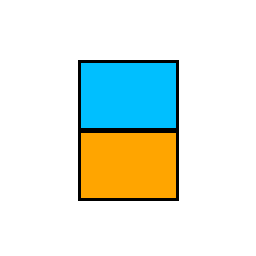

In [5]:
scene_image = make_color_blocksworld_image()
scene_image

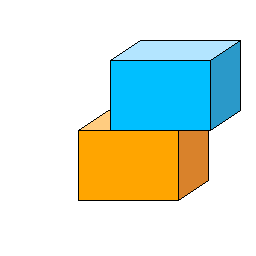

In [6]:
angled_scene_image = make_angled_blocksworld_image()
angled_scene_image

## 3. Build a first estimator with a deterministic backend

Let's put training wheels on first. Instead of jumping straight into a real model, we will use a tiny custom `VLMBackend` that already knows the answer for this toy scene.

That buys us two things immediately: the tutorial becomes perfectly runnable, and you get to see the exact contract a custom backend has to satisfy. If you ever want to plug in your own model wrapper later, this is the seam you will use.

One contract detail is especially important: each backend call receives a `generate` flag plus `**inference_kwargs`. In `logprobs` mode, the estimator calls your backend with `generate=False`; in `text_match` mode, it calls with `generate=True`.


In [7]:
class TutorialSceneVLM(VLMBackend):
    """A tiny deterministic backend for the tutorial notebook."""

    def __init__(self):
        self.received_prompts = []
        self.received_system_prompts = []

    def query(self, images, prompt, system_prompt=None, generate=False, **inference_kwargs):
        self.received_prompts.append(prompt)
        self.received_system_prompts.append(system_prompt)

        truth_map = {
            "Is the blue block on top of the orange block?": 0.85,
            "Is the orange block on top of the blue block?": 0.15,
            "Is the blue block clear?": 0.85,
            "Is the orange block clear?": 0.15,
        }

        yes_prob = 0.15
        for query_text, probability in truth_map.items():
            if query_text in prompt:
                yes_prob = probability
                break

        return VLMOutput(
            token_probs={"yes": yes_prob, "no": 1.0 - yes_prob},
            text="yes" if yes_prob >= 0.5 else "no",
        )


tutorial_vlm = TutorialSceneVLM()
estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=tutorial_vlm,
    query_translator=TemplateTranslator(TEMPLATE_MAP),
    user_prompt_template="Answer yes or no only: {query}",
    additional_instructions="Focus only on the visible colored blocks.",
)

print("Predicate -> query mapping:")
pprint(estimator.queries_dict)
print()
print("System prompt:")
print(estimator.system_prompt)


Predicate -> query mapping:
{'clear(blue)': 'Is the blue block clear?',
 'clear(orange)': 'Is the orange block clear?',
 'on(blue,blue)': 'Is the blue block on top of the blue block?',
 'on(blue,orange)': 'Is the blue block on top of the orange block?',
 'on(orange,blue)': 'Is the orange block on top of the blue block?',
 'on(orange,orange)': 'Is the orange block on top of the orange block?'}

System prompt:
A curious human is asking an artificial intelligence assistant yes or no questions. The assistant answers with one of two responses: YES or NO. The assistant's response should not include any additional text.
Additional Instructions and clarifications:
Focus only on the visible colored blocks.


This is also a good moment to notice why `TemplateTranslator` is such a comfortable default. It turns planner-shaped strings like `on(blue,orange)` into questions a model has a fighting chance of answering sensibly. In practice, that is usually what you want.


## 4. The three estimator outputs you will use most often

This is the part of the library you will touch most often, so it is worth slowing down for a second. `SemanticStateEstimator` gives you three ways to look at the same prediction pass, depending on how much uncertainty and debugging detail you want to keep around.

If you want a clean symbolic state, call the estimator directly. If you want soft confidence values, ask for probabilities. If you are tuning prompts or sanity-checking a backend, inspect the normalized `VLMOutput` objects from `estimate_raw()`.

You can also get stricter or more permissive on the fly by overriding the confidence threshold per call.


In [8]:
state = estimator([scene_image])
probabilities = estimator.estimate_probabilities([scene_image])
raw_outputs = estimator.estimate_raw([scene_image])
strict_state = estimator([scene_image], confidence=0.9)

assert isinstance(state, dict)
assert all(isinstance(value, bool) for value in state.values())
assert all(0.0 <= value <= 1.0 for value in probabilities.values())
assert isinstance(raw_outputs["on(blue,orange)"], VLMOutput)
assert state["on(blue,orange)"] is True
assert state["on(orange,blue)"] is False
assert state["on(blue,blue)"] is False

print("Boolean state at the default confidence=0.5:")
pprint(state)
print()
print("Probabilities:")
pprint(probabilities)
print()
print("The same estimator with a stricter per-call confidence=0.9:")
pprint(strict_state)
print()
print("Raw backend output for on(blue,orange):")
print(raw_outputs["on(blue,orange)"])


Boolean state at the default confidence=0.5:
{'clear(blue)': True,
 'clear(orange)': False,
 'on(blue,blue)': False,
 'on(blue,orange)': True,
 'on(orange,blue)': False,
 'on(orange,orange)': False}

Probabilities:
{'clear(blue)': 0.85,
 'clear(orange)': 0.15,
 'on(blue,blue)': 0.15,
 'on(blue,orange)': 0.85,
 'on(orange,blue)': 0.15,
 'on(orange,orange)': 0.15}

The same estimator with a stricter per-call confidence=0.9:
{'clear(blue)': False,
 'clear(orange)': False,
 'on(blue,blue)': False,
 'on(blue,orange)': False,
 'on(orange,blue)': False,
 'on(orange,orange)': False}

Raw backend output for on(blue,orange):
VLMOutput(token_probs={'yes': 0.85, 'no': 0.15000000000000002}, text='yes')


A good mental shortcut is this: the boolean state is just the probability state after someone has drawn a line in the sand. If your downstream code can benefit from uncertainty, hold onto the probabilities for as long as you can.


## 5. Calibrating probabilities with held-out examples

Raw model probabilities are often useful, but they are not automatically trustworthy. A model that says `0.8` does not necessarily mean “80% of the time this fluent is true.” `s3e` can fit a small post-hoc Platt scaling layer on held-out examples so that downstream thresholds and planning decisions operate on better-calibrated numbers.

This feature is only available in `probability_method="logprobs"` mode and requires the optional calibration extra:

```bash
pip install 's3e[calibration]'
```

At runtime you now have three modes:

- `calibrated=None`: auto mode. Use calibration if it is loaded, otherwise keep raw behavior.
- `calibrated=False`: always return raw uncalibrated probabilities.
- `calibrated=True`: require a fitted or loaded calibration profile.


In [ ]:
class CalibrationTutorialVLM(VLMBackend):
    def query(self, images, prompt, system_prompt=None, generate=False, **inference_kwargs):
        del system_prompt
        del generate
        del inference_kwargs

        example_id = images[0].getpixel((0, 0))[0]
        score_table = {
            (1, "Is the blue block on top of the orange block?"): 0.62,
            (1, "Is the orange block on top of the blue block?"): 0.20,
            (1, "Is the blue block clear?"): 0.78,
            (1, "Is the orange block clear?"): 0.30,
            (2, "Is the blue block on top of the orange block?"): 0.58,
            (2, "Is the orange block on top of the blue block?"): 0.25,
            (2, "Is the blue block clear?"): 0.72,
            (2, "Is the orange block clear?"): 0.35,
            (3, "Is the blue block on top of the orange block?"): 0.60,
            (3, "Is the orange block on top of the blue block?"): 0.22,
            (3, "Is the blue block clear?"): 0.75,
            (3, "Is the orange block clear?"): 0.33,
        }
        yes_prob = score_table[(example_id, prompt)]
        return VLMOutput(
            token_probs={"yes": yes_prob, "no": 1.0 - yes_prob},
            text="yes" if yes_prob >= 0.5 else "no",
        )


def calibration_demo_image(example_id: int):
    return [Image.new("RGB", (2, 2), color=(example_id, 0, 0))]


calibration_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=CalibrationTutorialVLM(),
    query_translator=TemplateTranslator(TEMPLATE_MAP),
)

held_out_examples = [
    CalibrationExample(
        images=calibration_demo_image(1),
        state_dict={
            "on(blue,orange)": True,
            "on(orange,blue)": False,
            "clear(blue)": True,
            "clear(orange)": False,
        },
    ),
    CalibrationExample(
        images=calibration_demo_image(2),
        state_dict={
            "on(blue,orange)": True,
            "on(orange,blue)": False,
            "clear(blue)": True,
            "clear(orange)": False,
        },
        problem=COLOR_BLOCKSWORLD_PROBLEM,
    ),
]

raw_probs = calibration_estimator.estimate_probabilities(calibration_demo_image(3), calibrated=False)
calibration_estimator.fit_platt_scaling(held_out_examples, scope="global")
global_probs = calibration_estimator.estimate_probabilities(calibration_demo_image(3), calibrated=None)
calibration_estimator.fit_platt_scaling(held_out_examples, scope="lifted")
lifted_probs = calibration_estimator.estimate_probabilities(calibration_demo_image(3), calibrated=True)

print("Raw probabilities:")
pprint(raw_probs)
print()
print("Global Platt-scaled probabilities:")
pprint(global_probs)
print()
print("Lifted-fluent Platt-scaled probabilities:")
pprint(lifted_probs)


## 6. Choosing a translator strategy

Think of translators as the bridge between planner language and model language. The planner thinks in predicates. The model would usually prefer a question. The translator is the part that keeps those two worlds from talking past each other.

The practical rule of thumb is simple: start with `TemplateTranslator`, drop to `IdentityTranslator` only when literal predicates are what you want, reach for `PrewrittenTranslator` when every prompt needs careful hand-authoring, and use `LLMTranslator` when you want the library to draft those prompts for you.

One subtle but important detail: translator choice also changes the estimator's default answer tokens. Literal predicate prompting assumes `true` / `false`, while natural-language prompting assumes `yes` / `no`.


In [9]:
identity_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=TutorialSceneVLM(),
)

prewritten_queries = {
    "on(blue,blue)": "Is the blue block stacked on itself?",
    "on(blue,orange)": "Is the blue block on top of the orange block?",
    "on(orange,blue)": "Is the orange block on top of the blue block?",
    "on(orange,orange)": "Is the orange block stacked on itself?",
    "clear(blue)": "Is the blue block clear?",
    "clear(orange)": "Is the orange block clear?",
}
prewritten_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=TutorialSceneVLM(),
    query_translator=PrewrittenTranslator(prewritten_queries),
)

print("Identity translator example:")
pprint(list(identity_estimator.queries_dict.items())[:2])
print()
print("Prewritten translator example:")
pprint(list(prewritten_estimator.queries_dict.items())[:2])
print()
print("Default tokens without translation:", identity_estimator.true_tokens, identity_estimator.false_tokens)
print("Default tokens with translation:", prewritten_estimator.true_tokens, prewritten_estimator.false_tokens)


Identity translator example:
[('on(blue,blue)', 'on(blue,blue)'), ('on(blue,orange)', 'on(blue,orange)')]

Prewritten translator example:
[('on(blue,blue)', 'Is the blue block stacked on itself?'),
 ('on(blue,orange)', 'Is the blue block on top of the orange block?')]

Default tokens without translation: ['true', 'True', 'TRUE'] ['false', 'False', 'FALSE']
Default tokens with translation: ['yes', 'Yes', 'YES'] ['no', 'No', 'NO']


## 7. When model outputs do not use yes/no

Models do not always answer in the vocabulary you hoped for. Sometimes `yes` and `no` are great. Sometimes a different pair of words is easier to elicit or easier to score. `s3e` gives you enough control to handle that without rewriting the whole estimator.

In the next toy example, the backend answers with `present` and `absent` instead. Same symbolic task, different answer words.


In [10]:
class PresentAbsentVLM(VLMBackend):
    def query(self, images, prompt, system_prompt=None, generate=False, **inference_kwargs):
        truth_map = {
            "Answer present or absent only: is the blue block on top of the orange block?": True,
            "Answer present or absent only: is the orange block on top of the blue block?": False,
            "Answer present or absent only: is the blue block clear?": True,
            "Answer present or absent only: is the orange block clear?": False,
            "Answer present or absent only: is the blue block stacked on itself?": False,
            "Answer present or absent only: is the orange block stacked on itself?": False,
        }

        is_true = truth_map.get(prompt, False)
        return VLMOutput(
            token_probs={
                "present": 0.9 if is_true else 0.1,
                "absent": 0.1 if is_true else 0.9,
            },
            text="present" if is_true else "absent",
        )


visibility_queries = {
    "on(blue,orange)": "Answer present or absent only: is the blue block on top of the orange block?",
    "on(orange,blue)": "Answer present or absent only: is the orange block on top of the blue block?",
    "clear(blue)": "Answer present or absent only: is the blue block clear?",
    "clear(orange)": "Answer present or absent only: is the orange block clear?",
    "on(blue,blue)": "Answer present or absent only: is the blue block stacked on itself?",
    "on(orange,orange)": "Answer present or absent only: is the orange block stacked on itself?",
}

custom_token_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=PresentAbsentVLM(),
    query_translator=PrewrittenTranslator(visibility_queries),
    true_tokens=["present"],
    false_tokens=["absent"],
)
text_match_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=PresentAbsentVLM(),
    query_translator=PrewrittenTranslator(visibility_queries),
    true_tokens=["present"],
    false_tokens=["absent"],
    probability_method="text_match",
)

print("Custom token groups with logprobs:")
pprint(custom_token_estimator.estimate_probabilities([scene_image]))
print()
print("The same setup using text_match on generated text:")
pprint(text_match_estimator.estimate_probabilities([scene_image]))


Custom token groups with logprobs:
{'clear(blue)': 0.9,
 'clear(orange)': 0.1,
 'on(blue,blue)': 0.1,
 'on(blue,orange)': 0.9,
 'on(orange,blue)': 0.1,
 'on(orange,orange)': 0.1}

The same setup using text_match on generated text:
{'clear(blue)': 1.0,
 'clear(orange)': 0.0,
 'on(blue,blue)': 0.0,
 'on(blue,orange)': 1.0,
 'on(orange,blue)': 0.0,
 'on(orange,orange)': 0.0}


Here is the practical takeaway: use `logprobs` when the backend is actually surfacing the answer tokens you care about, and switch to `text_match` when you can strongly coerce the model into a short, exact answer. Neither is universally better; the right choice depends on how your model behaves.


### A quick note on backend kwargs

There are now two different kwargs channels in `SemanticStateEstimator`, and keeping them separate will save you a lot of confusion:

- `vlm_kwargs` are for backend construction time (model/client setup).
- `inference_kwargs` are for per-query runtime inference options.

For custom backends, this means your `query(...)` or `query_batch(...)` implementation should accept both `generate` and `**inference_kwargs`, and apply `inference_kwargs` during the actual model call.

In practical terms: `probability_method="logprobs"` drives `generate=False`, while `probability_method="text_match"` drives `generate=True`.


In [11]:
class DebugKwargsVLM(VLMBackend):
    """Tiny backend that records mode and inference kwargs."""

    def __init__(self):
        self.calls = []

    def query(self, images, prompt, system_prompt=None, generate=False, **inference_kwargs):
        self.calls.append({"generate": generate, "inference_kwargs": dict(inference_kwargs)})
        if generate:
            return VLMOutput(token_probs={}, text="yes")
        return VLMOutput(token_probs={"yes": 0.8, "no": 0.2}, text="yes")


logprobs_debug_vlm = DebugKwargsVLM()
logprobs_debug_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=logprobs_debug_vlm,
    query_translator=TemplateTranslator(TEMPLATE_MAP),
    inference_kwargs={"temperature": 0.2},
)
out_prob = logprobs_debug_estimator.estimate_probabilities([scene_image])

text_match_debug_vlm = DebugKwargsVLM()
text_match_debug_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=text_match_debug_vlm,
    query_translator=TemplateTranslator(TEMPLATE_MAP),
    probability_method="text_match",
    inference_kwargs={"max_new_tokens": 4},
)
out_text = text_match_debug_estimator.estimate_probabilities([scene_image])

print("First logprobs call (generate should be False):")
pprint(logprobs_debug_vlm.calls[0])
print('output:', out_prob)
print()
print("First text_match call (generate should be True):")
pprint(text_match_debug_vlm.calls[0])
print('output:', out_text)

First logprobs call (generate should be False):
{'generate': False, 'inference_kwargs': {'temperature': 0.2}}
output: {'on(blue,blue)': 0.8, 'on(blue,orange)': 0.8, 'on(orange,blue)': 0.8, 'on(orange,orange)': 0.8, 'clear(blue)': 0.8, 'clear(orange)': 0.8}

First text_match call (generate should be True):
{'generate': True, 'inference_kwargs': {'max_new_tokens': 4}}
output: {'on(blue,blue)': 1.0, 'on(blue,orange)': 1.0, 'on(orange,blue)': 1.0, 'on(orange,orange)': 1.0, 'clear(blue)': 1.0, 'clear(orange)': 1.0}


## 8. Multiple images, averaging, and batching

This is where the cost model starts to matter. Every grounded predicate is a question, and every image is another piece of evidence, so runtime can grow faster than you expect.

`s3e` gives you a few levers to manage that. You can send all images together, average across per-image estimates, and control how many predicate queries travel together in one batch. The examples below use two views of the same scene: one straight-on, one from a different angle.


In [12]:
class ViewAwareVLM(VLMBackend):
    def query(self, images, prompt, system_prompt=None, generate=False, **inference_kwargs):
        image = images[0]
        angled_view = image.getpixel((225, 90)) != (255, 255, 255)
        if "blue block on top of the orange block" in prompt or "blue block clear" in prompt:
            yes_prob = 0.6 if angled_view else 0.9
        else:
            yes_prob = 0.4 if angled_view else 0.1
        return VLMOutput(token_probs={"yes": yes_prob, "no": 1.0 - yes_prob}, text="yes" if yes_prob >= 0.5 else "no")


average_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=ViewAwareVLM(),
    query_translator=TemplateTranslator(TEMPLATE_MAP),
    multi_image_strategy="average",
)
average_probabilities = average_estimator.estimate_probabilities([scene_image, angled_scene_image])

assert abs(average_probabilities["on(blue,orange)"] - 0.75) < 1e-9
print("Averaged probabilities across a head-on view and an angled view:")
pprint(average_probabilities)


Averaged probabilities across a head-on view and an angled view:
{'clear(blue)': 0.75,
 'clear(orange)': 0.25,
 'on(blue,blue)': 0.25,
 'on(blue,orange)': 0.75,
 'on(orange,blue)': 0.25,
 'on(orange,orange)': 0.25}


In [13]:
class BatchCountingVLM(VLMBackend):
    def __init__(self):
        self.batch_calls = 0

    def query(self, images, prompt, system_prompt=None, generate=False, **inference_kwargs):
        raise RuntimeError("query() should not be used when query_batch() is overridden")

    def query_batch(self, images, prompts, system_prompt=None, generate=False, **inference_kwargs):
        self.batch_calls += 1
        results = []
        for prompt in prompts:
            yes_prob = 0.8 if "blue block" in prompt else 0.2
            results.append(VLMOutput(token_probs={"yes": yes_prob, "no": 1.0 - yes_prob}, text="yes" if yes_prob >= 0.5 else "no"))
        return results


batch_vlm = BatchCountingVLM()
batch_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=batch_vlm,
    query_translator=TemplateTranslator(TEMPLATE_MAP),
    batch_size=2,
)
_ = batch_estimator.estimate_raw([scene_image])

assert batch_vlm.batch_calls == 3
print("With 6 grounded predicates and batch_size=2, the estimator made", batch_vlm.batch_calls, "batch calls.")


With 6 grounded predicates and batch_size=2, the estimator made 3 batch calls.


## 9. Swapping to a new planning problem

Imagine your planner moves on to a new problem instance: same domain, different objects, different grounded predicates. You do not necessarily need to rebuild everything from scratch.

`swap_problem(...)` is the quick way to refresh the planning problem and query set. The catch is that it leaves your prompt and token configuration alone. If those settings were generic, great. If they were tightly tied to the old problem, rebuild the estimator and save yourself a confusing afternoon.


In [14]:
swap_demo = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=TutorialSceneVLM(),
    query_translator=TemplateTranslator(TEMPLATE_MAP),
)
before_count = len(swap_demo.queries_dict)
swap_demo.swap_problem(COLOR_BLOCKSWORLD_DOMAIN, COLOR_BLOCKSWORLD_PROBLEM_3)
after_count = len(swap_demo.queries_dict)

assert before_count == 6
assert after_count == 12

print(f"Grounded predicates: {before_count} -> {after_count}")
print("A few queries after the swap:")
pprint(list(swap_demo.queries_dict.items())[:5])


Grounded predicates: 6 -> 12
A few queries after the swap:
[('on(blue,blue)', 'Is the blue block on top of the blue block?'),
 ('on(blue,orange)', 'Is the blue block on top of the orange block?'),
 ('on(blue,green)', 'Is the blue block on top of the green block?'),
 ('on(orange,blue)', 'Is the orange block on top of the blue block?'),
 ('on(orange,orange)', 'Is the orange block on top of the orange block?')]


## 10. Real HuggingFace integration with a small instruct model

Time to take the training wheels off. Everything up to this point was about learning the workflow cleanly; now we plug in a real `HuggingFaceVLM` and run the same pipeline for real.

For this notebook, I picked `HuggingFaceTB/SmolVLM-256M-Instruct`. It is not a powerhouse, but it *does* follow simple instructions far better than the random tiny checkpoint we tried earlier, and it is still small enough to be a reasonable CPU-first demo.

Set expectations accordingly: this section is about integration and behavior, not about showing off world-class visual reasoning.


In [15]:
import torch
from transformers.utils import logging as hf_logging

TINY_HF_VLM_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"
warnings.filterwarnings("ignore", message=".*torch_dtype.*")
warnings.filterwarnings("ignore", message=".*fast processor.*")
hf_logging.set_verbosity_error()

hf_true_tokens = [" Yes", " yes", "Yes", "yes", "YES"]
hf_false_tokens = [" No", " no", "No", "no", "NO"]

print("Loading the tiny HuggingFace VLM (first run may download weights)...")
device = (
    "cuda" if torch.cuda.is_available()  # prefer NVIDIA GPU
    else "mps" if torch.mps.is_available()  # then Apple Silicon GPU
    else "cpu"  # fallback to CPU if no GPU is available
)
hf_vlm = HuggingFaceVLM(TINY_HF_VLM_ID, device_map=device)
hf_estimator = SemanticStateEstimator(
    COLOR_BLOCKSWORLD_DOMAIN,
    COLOR_BLOCKSWORLD_PROBLEM,
    vlm=hf_vlm,
    query_translator=TemplateTranslator(TEMPLATE_MAP),
    user_prompt_template="Answer with exactly one word, yes or no: {query}",
    true_tokens=hf_true_tokens,
    false_tokens=hf_false_tokens,
)
hf_probabilities = hf_estimator.estimate_probabilities([scene_image])
hf_raw = hf_estimator.estimate_raw([scene_image])

assert all(0.0 <= value <= 1.0 for value in hf_probabilities.values())
assert len(hf_raw) == 6

print("Model:", TINY_HF_VLM_ID)
print()
print("Estimated probabilities on the toy scene:")
pprint(hf_probabilities)
print()
print("Raw HuggingFace output for on(blue,orange):")
print(hf_raw["on(blue,orange)"])


Loading the tiny HuggingFace VLM (first run may download weights)...


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Model: HuggingFaceTB/SmolVLM-256M-Instruct

Estimated probabilities on the toy scene:
{'clear(blue)': 0.9570080965711747,
 'clear(orange)': 0.5490263222238428,
 'on(blue,blue)': 0.9882690456109259,
 'on(blue,orange)': 0.9874599134265605,
 'on(orange,blue)': 0.945085134585426,
 'on(orange,orange)': 0.9494355031986382}

Raw HuggingFace output for on(blue,orange):
VLMOutput(token_probs={' Yes': 0.9874039888381958, ' No': 0.012539499439299107, ' yes': 5.44409231224563e-05, 'Yes': 1.2738472605633433e-06, ' no': 5.565966034737357e-07, ' Neither': 4.604687831033516e-08, ' NO': 4.222469485171132e-08, 'yes': 3.312503693564395e-08, 'No': 2.8293653642208483e-08, ' Y': 2.1430906826935825e-08, ' Yeah': 1.114172931693247e-08, ' Let': 7.115882993957712e-09, ' It': 6.980978461967879e-09, ' Both': 5.616750620163202e-09, ' I': 5.488187682090029e-09, ' Sure': 4.908201400866119e-09, ' She': 4.607786596722008e-09, ' Okay': 3.4898683942685693e-09, ' Did': 3.215459232208673e-09, ' Ye': 2.762256423594067e-09}

If you only learn one debugging habit from the real-model section, make it this one: always peek at `estimate_raw()` before you over-interpret the probabilities. Small models have quirks, tokenization has quirks, and those quirks become much less mysterious once you look at the actual `VLMOutput`.


## 11. Auto-generating translators and caching them

Writing prompt templates by hand is fine when your domain is tiny. It gets old quickly once the domain becomes large or awkward. That is where `LLMTranslator` becomes handy: let a language model draft the natural-language questions once, then cache them so you do not keep paying for the same translation work.

The next cell mocks the OpenAI translation call, so you can see the cache workflow clearly without needing credentials.


In [16]:
translated_predicates = ["on(blue,orange)", "clear(blue)"]

with tempfile.TemporaryDirectory() as cache_dir:
    translated_calls = []

    def fake_openai_translate(model_id, predicate, system_prompt, **kwargs):
        translated_calls.append(predicate)
        return f"Does the image show {predicate}?"

    with patch("s3e.translation.llm._openai_translate", side_effect=fake_openai_translate), patch("s3e.translation.llm.tqdm", new=lambda items, **kwargs: items):
        translator = LLMTranslator("OpenAI/gpt-4o-mini", cache_dir=cache_dir)
        first_result = translator.translate(translated_predicates, COLOR_BLOCKSWORLD_DOMAIN, COLOR_BLOCKSWORLD_PROBLEM)
        second_result = translator.translate(translated_predicates, COLOR_BLOCKSWORLD_DOMAIN, COLOR_BLOCKSWORLD_PROBLEM)

    cache_key = make_cache_key("OpenAI/gpt-4o-mini", up_problem.name)
    cached_queries = load_cache(cache_dir, cache_key)
    save_cache(cache_dir, cache_key, {"clear(orange)": "Does the image show clear(orange)?"})
    merged_cache = load_cache(cache_dir, cache_key)

assert first_result == second_result
assert translated_calls == translated_predicates
assert "clear(orange)" in merged_cache

print("First translation pass:")
pprint(first_result)
print()
print("Cached queries loaded from disk:")
pprint(cached_queries)
print()
print("After save_cache() merged an extra entry:")
pprint(merged_cache)


First translation pass:
{'clear(blue)': 'Does the image show clear(blue)?',
 'on(blue,orange)': 'Does the image show on(blue,orange)?'}

Cached queries loaded from disk:
{'clear(blue)': 'Does the image show clear(blue)?',
 'on(blue,orange)': 'Does the image show on(blue,orange)?'}

After save_cache() merged an extra entry:
{'clear(blue)': 'Does the image show clear(blue)?',
 'clear(orange)': 'Does the image show clear(orange)?',
 'on(blue,orange)': 'Does the image show on(blue,orange)?'}


That is the sweet spot for the cache helpers in this repo: not as generic storage, but as a cheap memory for translator outputs you want to reuse.

One gotcha is worth remembering. The cache key depends on the model ID, the PDDL problem name, and the inference kwargs. So if you quietly change the domain or problem contents but keep the same problem name, the cache cannot read your mind. In that case, clear or refresh it manually.


## 12. Handing the estimated state back into planning code

Now for the satisfying part: turning model output back into planner-native objects. Once you have a `dict[str, bool]`, the PDDL helpers in `s3e` make it straightforward to step back into Unified Planning land.


In [17]:
roundtrip_domain, roundtrip_problem = get_pddl_strings(up_problem)
predicate_fnode = ground_predicate_str_to_fnode(up_problem, "on(blue,orange)")
true_fnode = bool_constant_to_fnode(up_problem, True)
up_compatible_state = convert_state_dict_to_up_compatible(up_problem, state)
up_state = state_dict_to_up_state(up_problem, state)

assert "(clear ?x - block)" in roundtrip_domain
assert "(on blue orange)" in roundtrip_problem
assert predicate_fnode.fluent().name == "on"

print("Grounded predicate converted to a Unified Planning FNode:")
print(predicate_fnode)
print()
print("Boolean constant as a Unified Planning expression:")
print(true_fnode)
print()
print("UP-compatible state mapping sample:")
pprint(list(up_compatible_state.items())[:2])
print()
print("Unified Planning state:")
print(up_state)


Grounded predicate converted to a Unified Planning FNode:
on(blue, orange)

Boolean constant as a Unified Planning expression:
true

UP-compatible state mapping sample:
[(on(blue, blue), false), (on(blue, orange), true)]

Unified Planning state:
{on(blue, orange): true, clear(blue): true}


## 13. Other backend options

We have only executed two backend paths in this notebook, but the public API has one more very convenient trick: you can often pass a model string instead of manually constructing the backend object yourself.

If the string starts with `OpenAI/`, `s3e` builds an `OpenAIVLM` (requires `[openai]` optional installation dependencies). Otherwise, it treats the string as a HuggingFace model ID and builds a `HuggingFaceVLM`. That makes small experiments pleasantly short.

Here is what the OpenAI version looks like:

```python
estimator = SemanticStateEstimator(
    domain_pddl,
    problem_pddl,
    vlm="OpenAI/gpt-4o",
    vlm_kwargs={"api_key": "..."},  # client construction kwargs
    inference_kwargs={"temperature": 0.2},  # per-query inference kwargs
    query_translator=TemplateTranslator(TEMPLATE_MAP),
)
state = estimator(images)
```

The same split applies to HuggingFace string construction as well: keep load-time options in `vlm_kwargs` (for example `device_map`) and runtime options in `inference_kwargs` (for example generation limits when using `text_match`).


## Takeaways

If you step away from this notebook remembering only a handful of ideas, make them these:

- `SemanticStateEstimator` is the center of gravity
- translators decide how planner facts become model questions
- `estimate_raw()` is your best friend when a model behaves strangely
- probabilities are often more useful than booleans until the last possible moment
- tiny HuggingFace models are great for checking the wiring, not for winning benchmarks
- the utility helpers let you move back into Unified Planning once you have a symbolic state

And if you decide to extend the package, the two interfaces to keep in your head are `QueryTranslator` and `VLMBackend`. Those are the doors new behavior usually walks through.
